**Name:** Richin Swaroop Dasari

**Course:** 2026 Summer - Advanced Big Data and Data Mining (MSCS-634-B01) - Second Bi-term

**Assignment:** Lab 5: Clustering Techniques - Hierarchical and DBSCAN Clustering

---

# Lab 5: Clustering Techniques - Hierarchical and DBSCAN Clustering

In this lab I work with the **Wine dataset** from `sklearn.datasets`, which has 13 chemical measurements taken from wines grown in the same region of Italy but derived from three different cultivars. I apply two clustering approaches - Agglomerative Hierarchical Clustering and DBSCAN - to see how well each one can recover meaningful groupings from the chemical measurements alone (without using the actual cultivar labels to fit the models), and I compare how the two algorithms behave and what their strengths and weaknesses turn out to be on this data.

## 1. Data Preparation and Exploration

I start by loading the dataset, taking a look at its structure and summary statistics, and standardizing the features so that no single measurement (like proline, which is on a much bigger scale than the others) ends up dominating the distance calculations that clustering depends on.

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score, homogeneity_score, completeness_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [2]:
# Load the Wine dataset
wine = load_wine(as_frame=True)
df = wine.frame  # 13 chemical feature columns + a 'target' column (cultivar 0, 1, or 2)

print("Shape:", df.shape)
df.head()


Shape: (178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [3]:
# Examine the dataset's structure
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  target          

In [4]:
# Summary statistics
df.describe()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [5]:
# Check for missing values, and look at how many wines belong to each cultivar
print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing values")
print()
print("Class balance (target = cultivar):")
print(df['target'].value_counts().sort_index())


Missing values per column:
0 total missing values

Class balance (target = cultivar):
target
0    59
1    71
2    48
Name: count, dtype: int64


In [6]:
# The features are on very different scales (e.g. proline is in the hundreds, while
# hue and nonflavanoid_phenols are under 1) - standardizing puts every feature on the
# same footing so clustering distances aren't dominated by whichever feature happens
# to have the largest raw numbers.
X = df.drop(columns=['target'])
y_true = df['target']  # kept aside only for evaluation later, not used to fit the clustering models

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature ranges before scaling:")
print(X.describe().loc[['min', 'max']].T)
print("\nAfter scaling, every feature has mean 0 and standard deviation 1.")


Feature ranges before scaling:
                                 min      max
alcohol                        11.03    14.83
malic_acid                      0.74     5.80
ash                             1.36     3.23
alcalinity_of_ash              10.60    30.00
magnesium                      70.00   162.00
total_phenols                   0.98     3.88
flavanoids                      0.34     5.08
nonflavanoid_phenols            0.13     0.66
proanthocyanins                 0.41     3.58
color_intensity                 1.28    13.00
hue                             0.48     1.71
od280/od315_of_diluted_wines    1.27     4.00
proline                       278.00  1680.00

After scaling, every feature has mean 0 and standard deviation 1.


Variance explained by the first 2 principal components: 55.41%


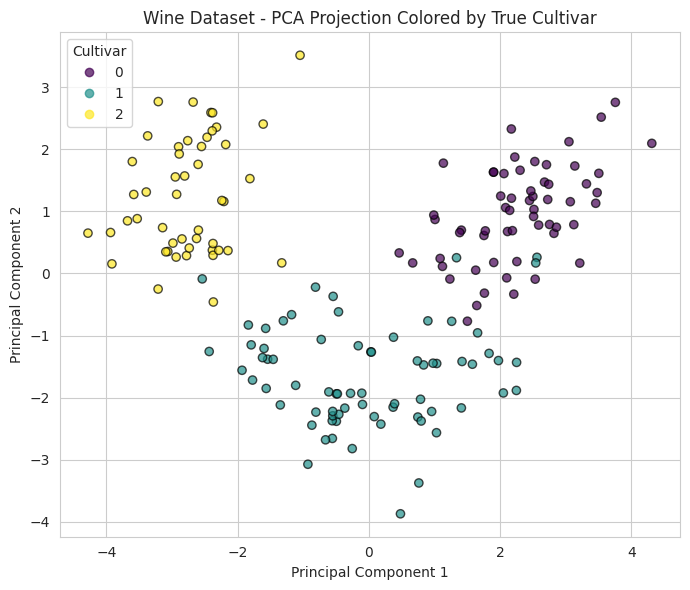

In [7]:
# Since we have 13 features, I use PCA to reduce to 2 components purely for visualization -
# the clustering itself is still done on the full standardized feature space, not on the PCA output.
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance explained by the first 2 principal components: {pca.explained_variance_ratio_.sum():.2%}")

plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='viridis', alpha=0.7, edgecolor='k')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Wine Dataset - PCA Projection Colored by True Cultivar')
plt.legend(*scatter.legend_elements(), title='Cultivar')
plt.tight_layout()
plt.show()


## 2. Hierarchical Clustering

I apply Agglomerative Hierarchical Clustering to the standardized data, trying a few different values of `n_clusters` to see how the grouping changes, then visualize the results on the PCA projection and build a dendrogram to see the merge structure directly.

In [8]:
# Try Agglomerative Clustering with a few different numbers of clusters
cluster_counts = [2, 3, 4, 5]
hier_labels = {}

for k in cluster_counts:
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(X_scaled)
    hier_labels[k] = labels
    sil = silhouette_score(X_scaled, labels)
    print(f"n_clusters={k}: silhouette score = {sil:.3f}")


n_clusters=2: silhouette score = 0.267
n_clusters=3: silhouette score = 0.277
n_clusters=4: silhouette score = 0.226
n_clusters=5: silhouette score = 0.187


n_clusters=3 lines up with what we'd expect, since the dataset actually comes from 3 cultivars. At n_clusters=2, two of the natural groups get merged together; at 4 or 5, one of the real groups gets artificially split into smaller pieces.


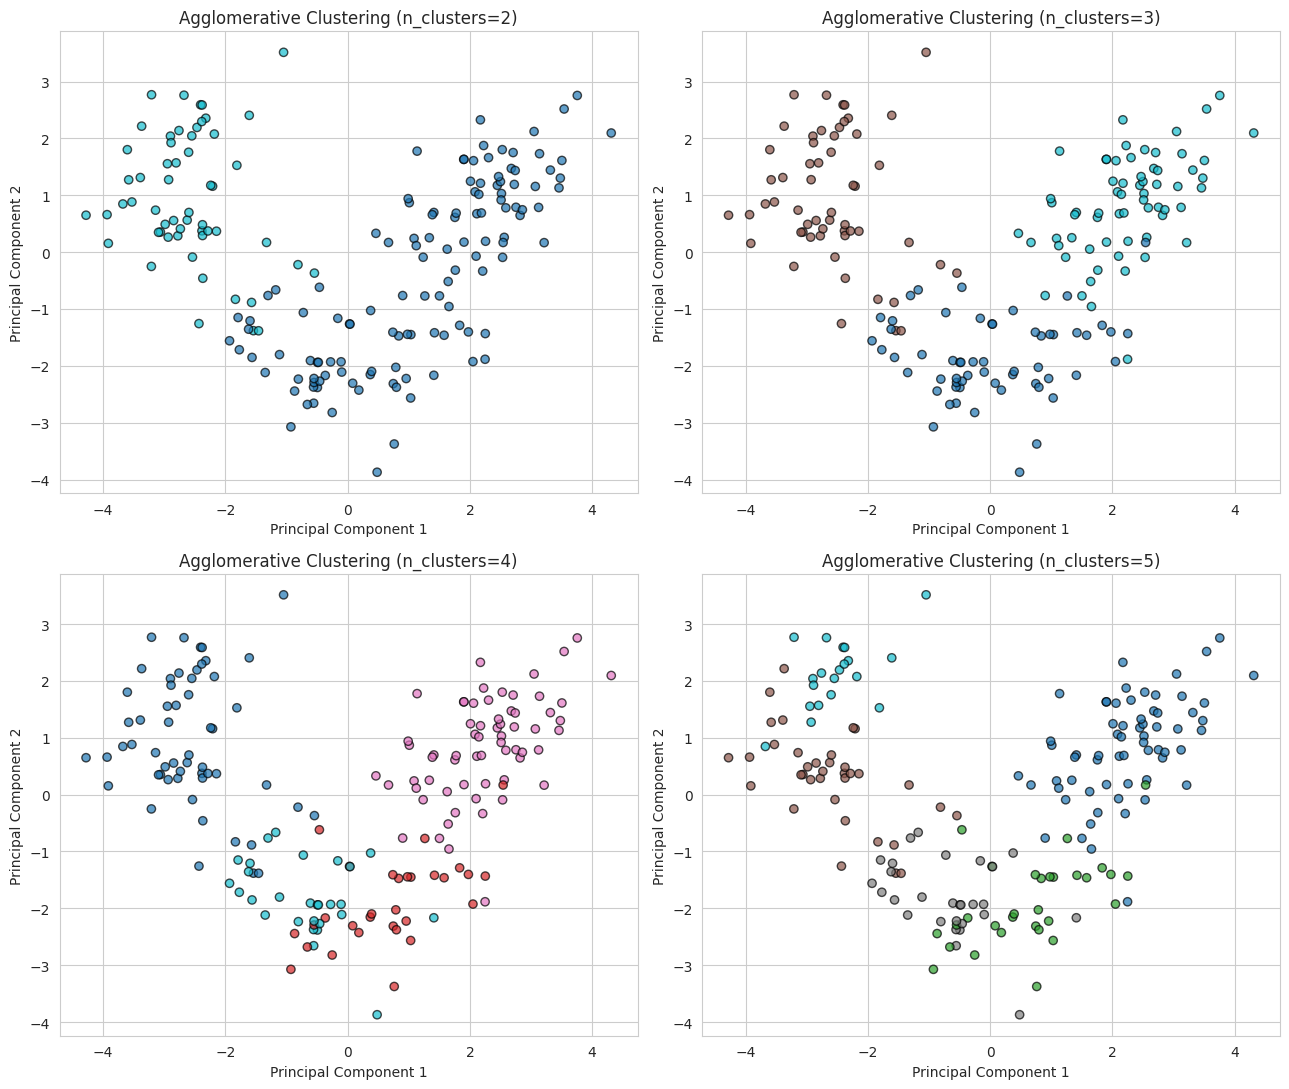

In [9]:
# Visualize the clusters for each n_clusters value on the PCA projection
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.ravel()

for ax, k in zip(axes, cluster_counts):
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=hier_labels[k], cmap='tab10', alpha=0.7, edgecolor='k')
    ax.set_title(f'Agglomerative Clustering (n_clusters={k})')
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')

plt.tight_layout()
plt.show()

print("n_clusters=3 lines up with what we'd expect, since the dataset actually comes from 3 "
      "cultivars. At n_clusters=2, two of the natural groups get merged together; at 4 or 5, "
      "one of the real groups gets artificially split into smaller pieces.")


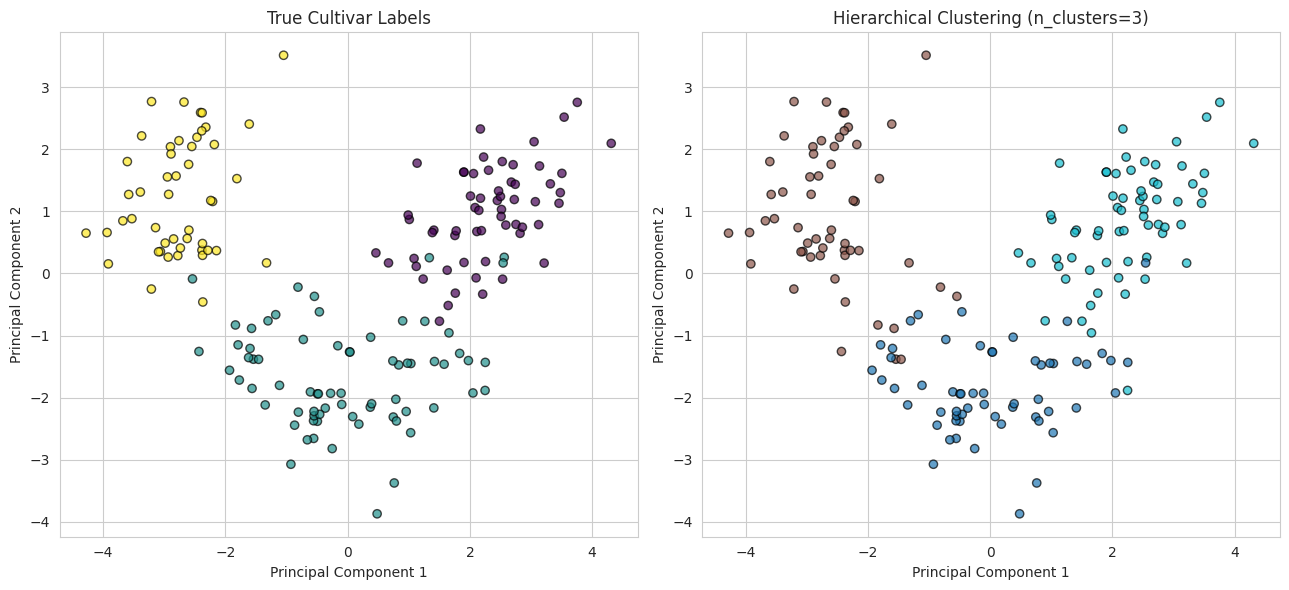

In [10]:
# Compare the n_clusters=3 result directly against the true cultivar labels
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='viridis', alpha=0.7, edgecolor='k')
axes[0].set_title('True Cultivar Labels')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=hier_labels[3], cmap='tab10', alpha=0.7, edgecolor='k')
axes[1].set_title('Hierarchical Clustering (n_clusters=3)')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')

plt.tight_layout()
plt.show()


Reading the dendrogram bottom-up: each merge joins the two closest clusters at that point, and the height of each join shows how (dis)similar the two things being merged were. The three tallest, cleanest branches near the top - well separated from where they'd merge into 2 clusters or 1 - are a good visual confirmation that 3 clusters is a natural place to cut this tree, matching what the silhouette scores suggested too.


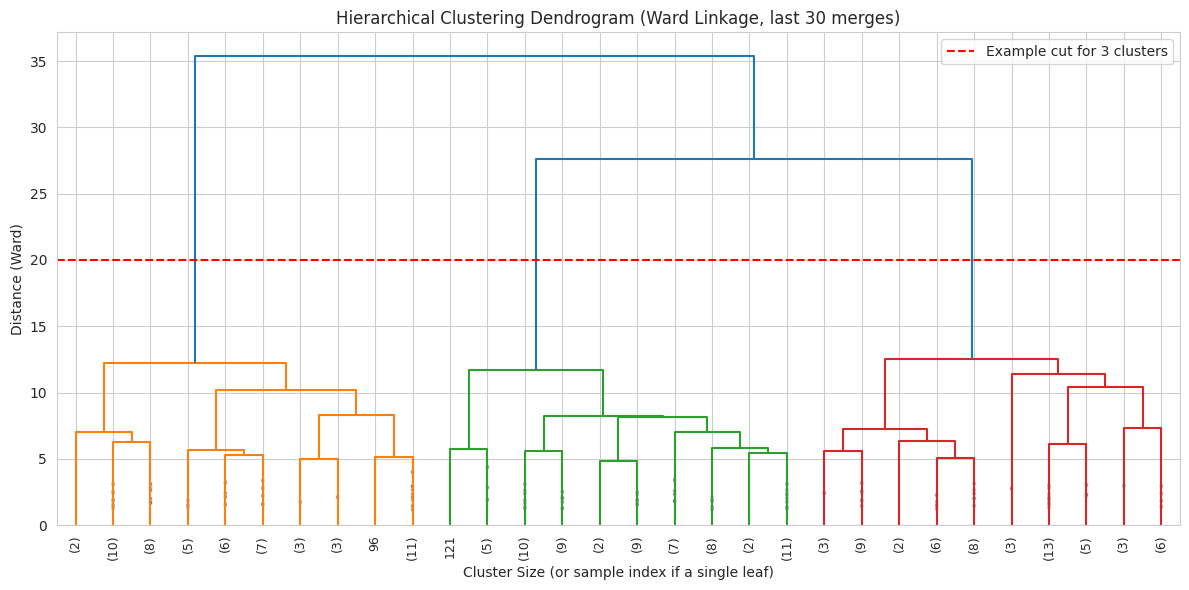

In [11]:
# Generate a dendrogram to see the merge structure directly. I use a sample-efficient
# 'ward' linkage (same criterion used above) and truncate the display to the last 30 merges
# so it stays readable.
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=9, show_contracted=True)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage, last 30 merges)')
plt.xlabel('Cluster Size (or sample index if a single leaf)')
plt.ylabel('Distance (Ward)')
plt.axhline(y=20, color='red', linestyle='--', label='Example cut for 3 clusters')
plt.legend()
plt.tight_layout()
plt.show()

print("Reading the dendrogram bottom-up: each merge joins the two closest clusters at that "
      "point, and the height of each join shows how (dis)similar the two things being merged "
      "were. The three tallest, cleanest branches near the top - well separated from where "
      "they'd merge into 2 clusters or 1 - are a good visual confirmation that 3 clusters is "
      "a natural place to cut this tree, matching what the silhouette scores suggested too.")


## 3. DBSCAN Clustering

DBSCAN doesn't need a target number of clusters up front - instead it groups points that are densely packed together and marks points in low-density regions as noise. I experiment with different `eps` (neighborhood radius) and `min_samples` values to see how sensitive the results are to those choices.

In [12]:
# Try a grid of eps and min_samples values and see how many clusters (and how much noise) each produces
eps_values = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
min_samples_values = [3, 5, 10]

dbscan_grid = []
for eps in eps_values:
    for ms in min_samples_values:
        model = DBSCAN(eps=eps, min_samples=ms)
        labels = model.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = int(np.sum(labels == -1))
        dbscan_grid.append({'eps': eps, 'min_samples': ms, 'n_clusters': n_clusters, 'n_noise': n_noise})

dbscan_grid_df = pd.DataFrame(dbscan_grid)
print(dbscan_grid_df.to_string(index=False))


 eps  min_samples  n_clusters  n_noise
 0.5            3           0      178
 0.5            5           0      178
 0.5           10           0      178
 1.0            3           0      178
 1.0            5           0      178
 1.0           10           0      178
 1.5            3           8      147
 1.5            5           0      178
 1.5           10           0      178
 2.0            3           5       64
 2.0            5           5       85
 2.0           10           1      139
 2.5            3           1       23
 2.5            5           1       24
 2.5           10           2       32
 3.0            3           2        7
 3.0            5           1       11
 3.0           10           1       12


Small eps values leave almost every point isolated as noise, since very few points have enough neighbors within such a tight radius. As eps grows, points start linking up into clusters, but push eps too far and everything collapses into a single giant cluster. min_samples has a similar effect - raising it makes DBSCAN pickier about what counts as a dense region, which produces more noise points at a given eps.


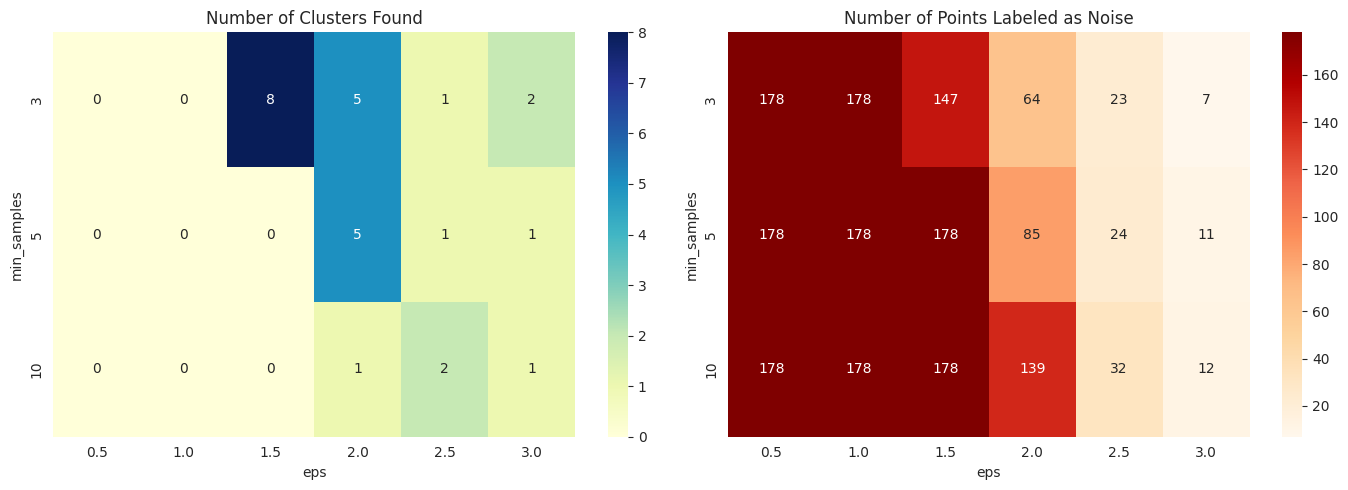

In [13]:
# Visualize how eps and min_samples affect the number of clusters found
pivot_clusters = dbscan_grid_df.pivot(index='min_samples', columns='eps', values='n_clusters')
pivot_noise = dbscan_grid_df.pivot(index='min_samples', columns='eps', values='n_noise')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(pivot_clusters, annot=True, fmt='d', cmap='YlGnBu', ax=axes[0])
axes[0].set_title('Number of Clusters Found')
axes[0].set_xlabel('eps')
axes[0].set_ylabel('min_samples')

sns.heatmap(pivot_noise, annot=True, fmt='d', cmap='OrRd', ax=axes[1])
axes[1].set_title('Number of Points Labeled as Noise')
axes[1].set_xlabel('eps')
axes[1].set_ylabel('min_samples')

plt.tight_layout()
plt.show()

print("Small eps values leave almost every point isolated as noise, since very few points "
      "have enough neighbors within such a tight radius. As eps grows, points start linking "
      "up into clusters, but push eps too far and everything collapses into a single giant "
      "cluster. min_samples has a similar effect - raising it makes DBSCAN pickier about what "
      "counts as a dense region, which produces more noise points at a given eps.")


In [14]:
# The eps values I tried above (0.5 to 3.0 in 0.5 steps) were a bit coarse, so I zoomed in
# around the 2.0-2.5 range where interesting things started happening, to find a combination
# that gives close to 3 clusters (matching the number of cultivars) without excessive noise.
fine_eps_values = [2.1, 2.2, 2.3, 2.4]
fine_min_samples = [3, 4, 5, 6]

fine_grid = []
for eps in fine_eps_values:
    for ms in fine_min_samples:
        labels = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = int(np.sum(labels == -1))
        fine_grid.append({'eps': eps, 'min_samples': ms, 'n_clusters': n_clusters, 'n_noise': n_noise})

fine_grid_df = pd.DataFrame(fine_grid)
print(fine_grid_df[fine_grid_df['n_clusters'] == 3].to_string(index=False))


 eps  min_samples  n_clusters  n_noise
 2.1            4           3       57
 2.1            5           3       62
 2.1            6           3       70
 2.2            3           3       44
 2.3            3           3       32


In [15]:
# eps=2.3, min_samples=3 gives 3 clusters with a moderate amount of noise (32 points out of
# 178) - a good balance between matching the expected cluster count and not throwing away too
# much data, so I use that as the featured DBSCAN result.
dbscan_final = DBSCAN(eps=2.3, min_samples=3)
dbscan_labels = dbscan_final.fit_predict(X_scaled)

n_clusters_final = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_final = int(np.sum(dbscan_labels == -1))
print(f"DBSCAN (eps=2.3, min_samples=3): {n_clusters_final} clusters found, {n_noise_final} noise points "
      f"out of {len(dbscan_labels)} total.")


DBSCAN (eps=2.3, min_samples=3): 3 clusters found, 32 noise points out of 178 total.


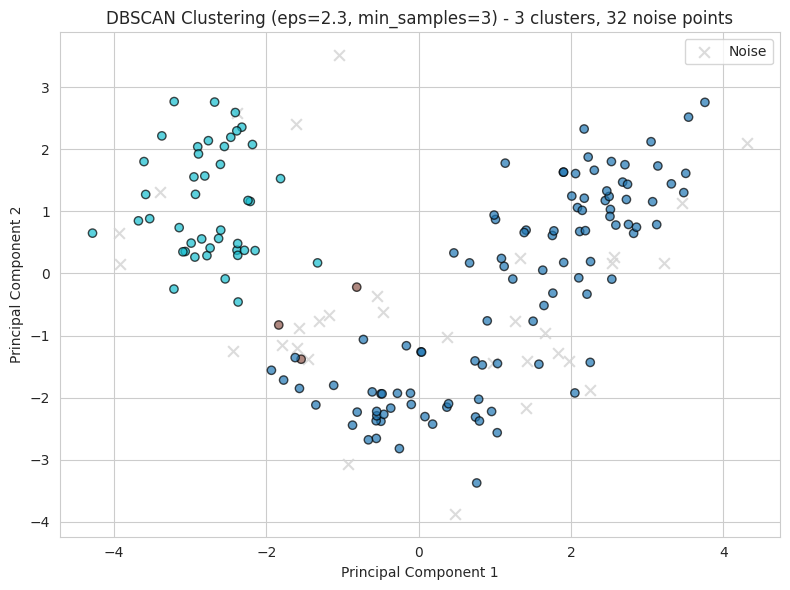

In [16]:
# Visualize the DBSCAN result, highlighting noise points separately
plt.figure(figsize=(8, 6))

# plot noise points first, in light gray, so real clusters are drawn on top
noise_mask = dbscan_labels == -1
plt.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1], c='lightgray', marker='x', s=60, label='Noise', alpha=0.8)

cluster_mask = ~noise_mask
scatter = plt.scatter(X_pca[cluster_mask, 0], X_pca[cluster_mask, 1], c=dbscan_labels[cluster_mask],
                       cmap='tab10', alpha=0.7, edgecolor='k')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title(f'DBSCAN Clustering (eps=2.3, min_samples=3) - {n_clusters_final} clusters, {n_noise_final} noise points')
plt.legend()
plt.tight_layout()
plt.show()


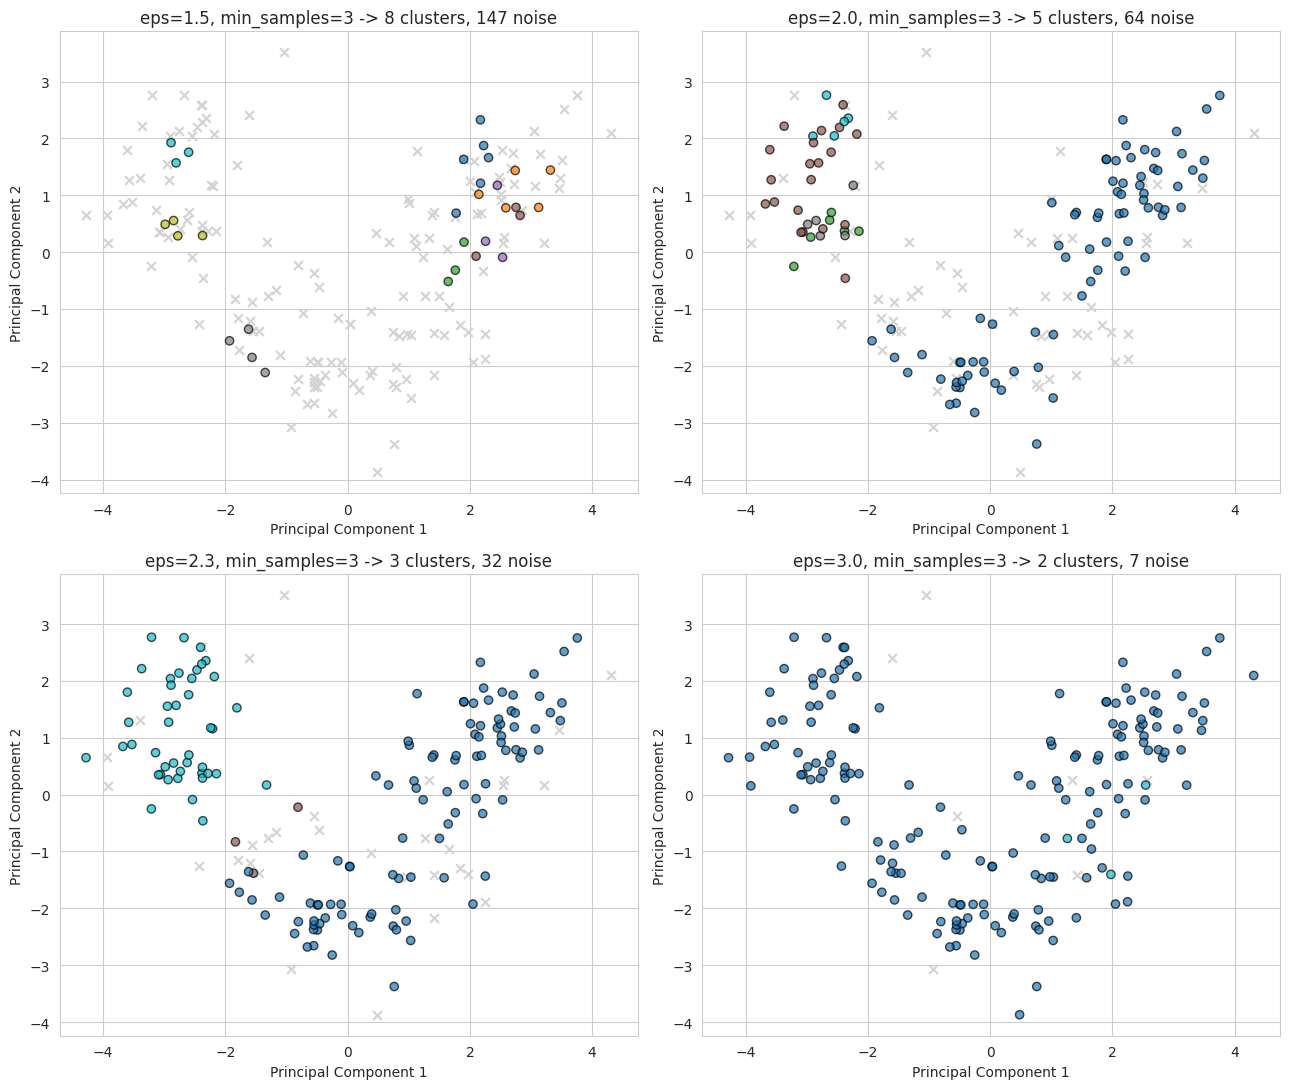

In [17]:
# Try a couple of the other eps/min_samples combinations side by side to see the practical effect
comparison_params = [(1.5, 3), (2.0, 3), (2.3, 3), (3.0, 3)]

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.ravel()

for ax, (eps, ms) in zip(axes, comparison_params):
    labels = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_scaled)
    noise = labels == -1
    n_clust = len(set(labels)) - (1 if -1 in labels else 0)

    ax.scatter(X_pca[noise, 0], X_pca[noise, 1], c='lightgray', marker='x', s=40, label='Noise')
    ax.scatter(X_pca[~noise, 0], X_pca[~noise, 1], c=labels[~noise], cmap='tab10', alpha=0.7, edgecolor='k')
    ax.set_title(f'eps={eps}, min_samples={ms} -> {n_clust} clusters, {int(noise.sum())} noise')
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')

plt.tight_layout()
plt.show()


In [18]:
# Evaluate clustering quality: Silhouette Score (doesn't need true labels - measures how
# well-separated/compact the clusters are), plus Homogeneity and Completeness (these do use
# the true cultivar labels, purely for evaluation purposes - not used to fit the model).
#
# For the silhouette score, DBSCAN's noise points (-1) are excluded, since silhouette isn't
# defined for a "noise" label the way it is for real clusters.
non_noise_mask = dbscan_labels != -1

sil_dbscan = silhouette_score(X_scaled[non_noise_mask], dbscan_labels[non_noise_mask])
sil_hier = silhouette_score(X_scaled, hier_labels[3])

hom_dbscan = homogeneity_score(y_true, dbscan_labels)
com_dbscan = completeness_score(y_true, dbscan_labels)

hom_hier = homogeneity_score(y_true, hier_labels[3])
com_hier = completeness_score(y_true, hier_labels[3])

metrics_df = pd.DataFrame({
    'Metric': ['Silhouette Score', 'Homogeneity Score', 'Completeness Score'],
    'Hierarchical (n_clusters=3)': [sil_hier, hom_hier, com_hier],
    'DBSCAN (eps=2.3, min_samples=3)': [sil_dbscan, hom_dbscan, com_dbscan]
}).round(4)

metrics_df


,Metric,Hierarchical (n_clusters=3),"DBSCAN (eps=2.3, min_samples=3)"
0,Silhouette Score,0.2774,0.2249
1,Homogeneity Score,0.7904,0.4926
2,Completeness Score,0.7825,0.5122


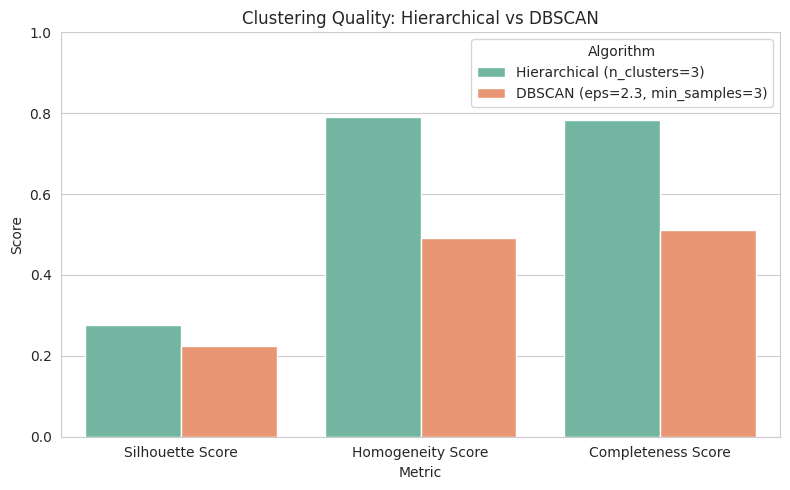

In [19]:
# Visualize the metric comparison
metrics_plot_df = metrics_df.melt(id_vars='Metric', var_name='Algorithm', value_name='Score')

plt.figure(figsize=(8, 5))
sns.barplot(data=metrics_plot_df, x='Metric', y='Score', hue='Algorithm', palette='Set2')
plt.title('Clustering Quality: Hierarchical vs DBSCAN')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## 4. Analysis and Insights

### Comparing Hierarchical and DBSCAN Clustering

- **Hierarchical clustering (n_clusters=3) matched the true cultivar structure noticeably better** than DBSCAN did on this dataset, with higher homogeneity and completeness scores. That makes sense given what the PCA plot of the true labels looks like - the three cultivars form roughly convex, evenly-sized blobs, which is exactly the shape Ward-linkage hierarchical clustering is good at finding.
- **DBSCAN struggled more here because the clusters have fairly similar density and don't have a lot of empty space between them** in the standardized 13-dimensional feature space. DBSCAN is built around the idea of dense regions separated by sparse ones, and when clusters butt up against each other with only a gradual density drop-off, DBSCAN either merges them into one cluster or has to mark a lot of the boundary points as noise to keep them apart.
- **The number of noise points DBSCAN produced was a real tradeoff.** Tightening `eps` labeled more borderline points as noise (points genuinely on the edge of a group, not necessarily true outliers), while loosening it too much merged separate cultivars into one blob. There wasn't an eps/min_samples combination that both kept noise low and recovered 3 clean clusters matching the 3 cultivars.

### How parameter choices influenced the outcomes

- For hierarchical clustering, **n_clusters was the main lever**, and picking it well benefited a lot from checking the silhouette score across a few options and looking at the dendrogram - both pointed to 3 as a sensible number, which also happens to match the number of actual cultivars (though in a real unsupervised setting we wouldn't know that in advance).
- For DBSCAN, **eps mattered much more than min_samples** in this case. Small changes in eps swung the result from "almost everything is noise" to "everything merges into one cluster" fairly quickly, while min_samples mostly nudged how much noise there was at a given eps rather than fundamentally changing the cluster count.

### Strengths and weaknesses of each algorithm

- **Hierarchical clustering** worked well here because it doesn't assume anything about cluster density, and it gave me a dendrogram I could actually inspect to sanity-check the number of clusters instead of just guessing. The tradeoff is that I still had to pick `n_clusters` myself, and it's not built to handle noise or outliers - every point ends up assigned to some cluster whether it really belongs there or not.
- **DBSCAN's ability to flag noise and to not require a predetermined number of clusters** is a real advantage in messier, real-world data with actual outliers. On this particular dataset, though, since the "real" groups are all similarly dense and touch each other, DBSCAN's core density assumption didn't fit as well, and it needed a fair amount of parameter tweaking to get anywhere close to the true structure.
- **Overall**, for data like this - where the underlying groups are roughly equal-density blobs - hierarchical clustering was the better fit. DBSCAN would likely have the edge on a dataset with irregularly shaped clusters, varying densities, and genuine outliers that shouldn't be forced into any cluster.

---

### A Few Implementation Notes

I used a fixed `RANDOM_STATE` for PCA so the 2D projection is reproducible (Agglomerative Clustering and DBSCAN are themselves deterministic given the same data and parameters, so no seed was needed there). All clustering was done on the full standardized 13-feature space, not on the 2D PCA output - PCA was only used to make the results visualizable, never to fit the models. The true cultivar labels were kept aside and only used for the homogeneity/completeness metrics at the end, never during clustering itself, to keep the exercise genuinely unsupervised.